# SVM

## Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import time

from scipy.sparse import csr_matrix, hstack

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)

import matplotlib.pyplot as plt


In [3]:
# data = pd.read_csv("/content/cleaned_sentiment140.csv")
features = pd.read_csv("/content/handcrafted_features.csv")

tfidf = joblib.load("/content/tfidf_vectorizer.pkl")
scaler = joblib.load("/content/feature_scaler.pkl")

train_idx = joblib.load("/content/train_indices.pkl")
test_idx = joblib.load("/content/test_indices.pkl")

In [4]:
# print(data.shape)
print(features.shape)

print(len(train_idx))
print(len(test_idx))

(1592688, 19)
1274150
318538


In [5]:
x_train = joblib.load("/content/x_train.pkl")
x_test = joblib.load("/content/x_test.pkl")

y_train = joblib.load("/content/y_train.pkl")
y_test = joblib.load("/content/y_test.pkl")

In [6]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
print(features.shape)

(1274150,)
(318538,)
(1274150,)
(318538,)
(1592688, 19)


In [7]:
x_train_tf = tfidf.transform(x_train)
x_test_tf = tfidf.transform(x_test)

In [8]:
print(x_train_tf.shape)
print(x_test_tf.shape)

(1274150, 50000)
(318538, 50000)


In [9]:
features_train = features.loc[x_train.index]
features_test = features.loc[x_test.index]

print(features_train.shape)
print(features_test.shape)

(1274150, 19)
(318538, 19)


In [10]:
features_train_scaled = scaler.transform(features_train)
features_test_scaled = scaler.transform(features_test)

In [11]:
features_train_sparse = csr_matrix(features_train_scaled)
features_test_sparse = csr_matrix(features_test_scaled)

In [12]:
x_train_final = hstack([x_train_tf, features_train_sparse])
x_test_final = hstack([x_test_tf, features_test_sparse])

print(x_train_final.shape)
print(x_test_final.shape)

(1274150, 50019)
(318538, 50019)


## Base Model

In [13]:
# C=1.0 → Standard regularization (good baseline)
# loss="squared_hinge" → Default
# max_iter=5000 → iterations for convergence
# dual="auto" → scikit-learn choose the best optimization strategy
# verbose=1 → Shows training progress

svm_model = LinearSVC(
    C=1.0,
    loss="squared_hinge",
    max_iter=5000,
    dual='auto',
    random_state=42,
    verbose=1
)

In [14]:
import time
start = time.time()
svm_model.fit(x_train_final, y_train)
end = time.time()

print(f"Training Time: {end-start:.2f} Seconds")

[LibLinear]Training Time: 408.94 Seconds


In [15]:
y_pred = svm_model.predict(x_test_final)

In [16]:
# Instead of predict Proba we use Scores
scores = svm_model.decision_function(x_test_final)

In [17]:
roc_auc = roc_auc_score(y_test, scores)

In [18]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"Roc_Auc Score : {roc_auc:.4f}")

Accuracy : 0.7961
Precision: 0.7851
Recall   : 0.8155
F1 Score : 0.8000
Roc_Auc Score : 0.8774


In [19]:
# Classification Report
print(f"Classification_Report: \n \n {classification_report(y_test, y_pred)}")

Classification_Report: 
 
               precision    recall  f1-score   support

           0       0.81      0.78      0.79    159267
           1       0.79      0.82      0.80    159271

    accuracy                           0.80    318538
   macro avg       0.80      0.80      0.80    318538
weighted avg       0.80      0.80      0.80    318538



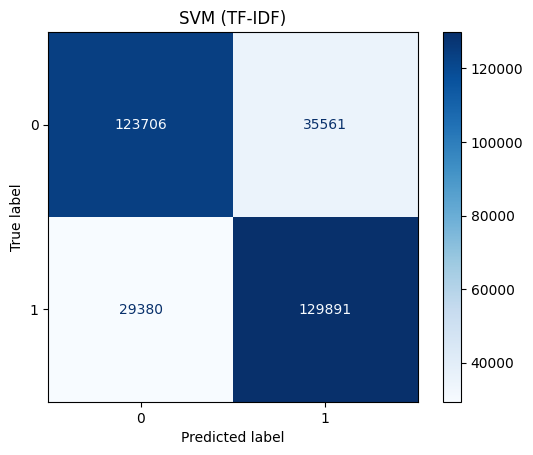

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap = "Blues"
)

plt.title("SVM (TF-IDF)")
plt.show()

In [21]:
joblib.dump(svm_model, 'svm_model.pkl')

['svm_model.pkl']